

**⚠️ Historical artifact (2026-05-27):** v2-256 was retired in favor of
per-cell v2-1024 as chorus's production model. This notebook preserves the
comparison record; re-executing it will fail because the v2-256 ckpts +
`epinformerseq_v2_256bp_percell_pertrack.npz` CDF have been deleted, and
the v2-1024 CDF was renamed to `epinformerseq_pertrack.npz`.

# EPInformer-seq v2 — 256-bp vs 1024-bp window comparison

Both per-cell trained, same architecture family (`PerCellProfileNet` + frozen per-cell `BiasNet`, dilated CNN + multinomial-NLL profile + log10-count head, ChromBPNet recipe). The only differences:

| | v2-256bp | v2-1024bp |
|---|---|---|
| input window | 256 bp | 1024 bp |
| receptive-field depth (n_dilated) | 7 (1,2,4,8,16,32,64) | 9 (1,2,4,8,16,32,64,128,256) |
| main params | 110 K | 136 K |
| bias params | 31 K | 37 K |
| training peaks per cell | DNase ∪ H3K27ac, central-256 slice | DNase ∪ H3K27ac, full 1024-bp |
| h5 source | central 256 bp of the 1024-bp h5 entries | full 1024-bp h5 entries |
| BAM source | per-rep (ENCODE-recommended single rep per assay) | per-rep (same) |

**Per-rep retraining (2026-05-26):** Both models retrained on per-rep ENCODE BAMs (ENCODE's `recommended=true` flag, one rep per assay) instead of the original multi-rep merged BAMs. v2-256 benefits substantially (HepG2 +0.067, A549 **+0.159** DNase r); v2-1024 is essentially unchanged. Cross-cell averaged, v2-1024 still wins by 0.046 r and remains the recommended default. Merged-BAM trainings retired.

**Why this comparison matters:**

The 3-way v1/v2-256/v2-1024 decomposition (from `klf1_epinformerseq_v1_vs_v2.ipynb` §9) showed that ~3/4 of the v1→v2 r gap is target formulation (max-product-sqrt → integrated count + bias + multi-task profile) and ~1/4 is window size. Here we isolate the window-size axis — what does the extra 768 bp of flanking context buy you at the KLF1 locus, and at what cost?

**Validated CREs (chr19, 1-based, K562):**

| # | Element | Distance to TSS | EffectSize | H3K27ac.RPM |
|---|---|---|---|---|
| 1 | 12,888,891–12,889,391 (proximal) | ~2 kb   | −0.169 | 1.71 |
| 2 | 12,867,151–12,867,931 (mid)      | ~20 kb  | −0.026 | 2.82 |
| 3 | 12,847,511–12,848,011 (distal)   | ~39 kb  | −0.058 | 0.32 |

**Checkpoints (vendored locally, per-cell):**
- v2-256: `_epinformerseq_v2/per_cell_256bp/<cell>/main.pt` + `per_cell_256bp_bias/<cell>/bias.pt`
- v2-1024: `_epinformerseq_v2/per_cell/<cell>/main.pt` + `bias/<cell>/bias.pt`

**DHS-augmented baseline CDFs** (90th-pct threshold per cell):
- v2-256: `~/.chorus/backgrounds/epinformerseq_v2_256bp_percell_pertrack.npz`
- v2-1024: `~/.chorus/backgrounds/epinformerseq_v2_percell_pertrack.npz`

**Runtime:** ~2-3 min on MPS / CUDA. Locus inference: v2-256 sliding 256/16 = ~3.7 k windows × 2 cells; v2-1024 sliding 1024/64 = ~920 windows × 2 cells.


## Setup


In [1]:

import os, warnings, time, textwrap, json
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
warnings.filterwarnings('ignore', message='.*padding="same".*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

import chorus
from chorus.utils import get_genome, extract_sequence

genome_path = get_genome('hg38')
print('hg38 genome:', genome_path)

V2_256_DIR      = (Path.cwd() / '_epinformerseq_v2' / 'per_cell_256bp').resolve()
V2_256_BIAS_DIR = (Path.cwd() / '_epinformerseq_v2' / 'per_cell_256bp_bias').resolve()
V2_1024_DIR     = (Path.cwd() / '_epinformerseq_v2' / 'per_cell').resolve()
V2_1024_BIAS_DIR = (Path.cwd() / '_epinformerseq_v2' / 'bias').resolve()
for d in (V2_256_DIR, V2_256_BIAS_DIR, V2_1024_DIR, V2_1024_BIAS_DIR):
    assert d.exists(), f'missing: {d}'

CELLS = ['K562', 'GM12878']
for c in CELLS:
    assert (V2_256_DIR / c / 'main.pt').exists(),       f'missing v2-256 {c}'
    assert (V2_256_BIAS_DIR / c / 'bias.pt').exists(),  f'missing v2-256 bias {c}'
    assert (V2_1024_DIR / c / 'main.pt').exists(),      f'missing v2-1024 {c}'
    assert (V2_1024_BIAS_DIR / c / 'bias.pt').exists(), f'missing v2-1024 bias {c}'


hg38 genome: /Users/jieconglin/Documents/hpc-projects/chorus/genomes/hg38.fa


## § 1. The 3 validated KLF1 enhancers


In [2]:

EPCRISPR_TSV = '../walkthroughs/CRISPR_valid_CREs/EPCrisprBenchmark_combined_data.training_K562.GRCh38.tsv.gz'
df = pd.read_csv(EPCRISPR_TSV, sep='\t')
klf1 = df[df['measuredGeneSymbol'] == 'KLF1'].copy()
klf1_pos = klf1[klf1['Regulated'] == True].copy().reset_index(drop=True)
klf1_pos['midpoint'] = (klf1_pos['chromStart'] + klf1_pos['chromEnd']) // 2
klf1_pos['width']    = klf1_pos['chromEnd'] - klf1_pos['chromStart']
klf1_pos = klf1_pos.sort_values('midpoint').reset_index(drop=True)
klf1_pos['label']    = ['distal', 'mid', 'proximal']

print(f'KLF1 candidate CREs : {len(klf1)}')
print(f'KLF1 Regulated      : {len(klf1_pos)}')
print()
display_cols = ['label', 'chrom', 'chromStart', 'chromEnd', 'midpoint', 'width',
                'distanceToTSS', 'EffectSize', 'H3K27ac.RPM']
klf1_pos[display_cols]


KLF1 candidate CREs : 82
KLF1 Regulated      : 3



,label,chrom,chromStart,chromEnd,midpoint,width,distanceToTSS,EffectSize,H3K27ac.RPM
0,distal,chr19,12847511,12848011,12847761,500,39441,-0.057784,0.317648
1,mid,chr19,12867151,12867931,12867541,780,19661,-0.026087,2.818881
2,proximal,chr19,12888891,12889391,12889141,500,1937,-0.169294,1.707113



## § 2. Locus geometry

A 60-kb display window centered between the proximal + distal enhancers. v2-256 tiles at 256/16; v2-1024 tiles at 1024/64.


In [3]:

CHROM         = 'chr19'
TSS           = 12_887_180
LOCUS_CENTER  = (klf1_pos['midpoint'].iloc[0] + klf1_pos['midpoint'].iloc[-1]) // 2
DISPLAY_HALF  = 30_000
DISPLAY_START = LOCUS_CENTER - DISPLAY_HALF
DISPLAY_END   = LOCUS_CENTER + DISPLAY_HALF

V256_WINDOW  = 256;  V256_STRIDE  = 16
V1024_WINDOW = 1024; V1024_STRIDE = 64

locus_seq = extract_sequence(f'{CHROM}:{DISPLAY_START + 1}-{DISPLAY_END}', str(genome_path)).upper()
assert len(locus_seq) == DISPLAY_END - DISPLAY_START

n_v256  = (len(locus_seq) - V256_WINDOW)  // V256_STRIDE  + 1
n_v1024 = (len(locus_seq) - V1024_WINDOW) // V1024_STRIDE + 1
print(f'Display: {CHROM}:{DISPLAY_START:,}-{DISPLAY_END:,}  ({DISPLAY_END-DISPLAY_START:,} bp)')
print(f'Center : {LOCUS_CENTER:,}    TSS: {TSS:,}    Δto-center: {TSS-LOCUS_CENTER:+,} bp')
print()
print(f'v2-256  sliding: window={V256_WINDOW},  stride={V256_STRIDE}  → {n_v256:,} forward passes per cell')
print(f'v2-1024 sliding: window={V1024_WINDOW}, stride={V1024_STRIDE} → {n_v1024:,} forward passes per cell')


Display: chr19:12,838,451-12,898,451  (60,000 bp)
Center : 12,868,451    TSS: 12,887,180    Δto-center: +18,729 bp

v2-256  sliding: window=256,  stride=16  → 3,735 forward passes per cell
v2-1024 sliding: window=1024, stride=64 → 922 forward passes per cell



## § 3. v2-256bp per-bp profile inference at the KLF1 locus

`PerCellProfileNet256` (110 K) + frozen `BiasNet256` (31 K) per cell. Forward pass: `softmax(main + bias) × 10^log_count` → per-bp predicted counts.


In [4]:

from scipy.ndimage import gaussian_filter1d
SMOOTH_SIGMA = 0   # raw per-bp; bump to 15 for footprint-scale denoise

epi_oracle = chorus.create_oracle('epinformerseq', use_environment=True)

# ─── v2-256bp ───
v256_starts  = list(range(0, len(locus_seq) - V256_WINDOW + 1, V256_STRIDE))
v256_windows = [locus_seq[s:s + V256_WINDOW] for s in v256_starts]

def _v256_script(cell, windows):
    main_ckpt = V2_256_DIR / cell / 'main.pt'
    bias_ckpt = V2_256_BIAS_DIR / cell / 'bias.pt'
    return textwrap.dedent(f'''
        import sys, numpy as np, torch
        sys.path.insert(0, {repr(str(V2_256_DIR))})
        from model import PerCellProfileNet256, BiasNet256
        def one_hot(s):
            a = np.zeros((4, len(s)), dtype=np.float32)
            for i, b in enumerate(s):
                if   b == "A": a[0, i] = 1.0
                elif b == "C": a[1, i] = 1.0
                elif b == "G": a[2, i] = 1.0
                elif b == "T": a[3, i] = 1.0
            return a
        device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
        main = PerCellProfileNet256()
        main.load_state_dict(torch.load({repr(str(main_ckpt))}, map_location="cpu", weights_only=False))
        main.eval().to(device)
        bias = BiasNet256()
        bias.load_state_dict(torch.load({repr(str(bias_ckpt))}, map_location="cpu", weights_only=False))
        bias.eval().to(device)

        seqs = {repr(windows)}
        BATCH = 256
        n = len(seqs)
        dnase_w = np.zeros((n, {V256_WINDOW}), dtype=np.float32)
        h3_w    = np.zeros((n, {V256_WINDOW}), dtype=np.float32)
        for i in range(0, n, BATCH):
            batch = seqs[i:i+BATCH]
            oh = np.stack([one_hot(s) for s in batch], axis=0)
            x = torch.from_numpy(oh).to(device)
            with torch.inference_mode():
                mp, mc = main(x); bp, _ = bias(x)
                soft  = torch.softmax(mp + bp, dim=-1)
                signal = soft * (10.0 ** mc).unsqueeze(-1)
            dnase_w[i:i+len(batch)] = signal[:, 0, :].cpu().numpy()
            h3_w[i:i+len(batch)]    = signal[:, 1, :].cpu().numpy()
        result = {{"dnase": dnase_w.tolist(), "h3k27ac": h3_w.tolist()}}
    ''')

def _overlap_add(starts, windows_n, result, n_bp, sigma=SMOOTH_SIGMA):
    dnase = np.asarray(result['dnase'],   dtype=np.float32)
    h3    = np.asarray(result['h3k27ac'], dtype=np.float32)
    d_acc = np.zeros(n_bp, dtype=np.float32)
    h_acc = np.zeros(n_bp, dtype=np.float32)
    cov   = np.zeros(n_bp, dtype=np.float32)
    for i, ws in enumerate(starts):
        d_acc[ws:ws + windows_n] += dnase[i]
        h_acc[ws:ws + windows_n] += h3[i]
        cov[ws:ws + windows_n]   += 1.0
    d = d_acc / np.maximum(cov, 1.0)
    h = h_acc / np.maximum(cov, 1.0)
    if sigma > 0:
        d = gaussian_filter1d(d, sigma=sigma)
        h = gaussian_filter1d(h, sigma=sigma)
    return d, h

n_bp = len(locus_seq)
v256_d, v256_h, v256 = {}, {}, {}
for cell in CELLS:
    t0 = time.time()
    r = epi_oracle.run_code_in_environment(_v256_script(cell, v256_windows), timeout=900)
    print(f'v2-256  {cell:<8s}: {len(v256_windows):,} windows in {time.time()-t0:.1f} s')
    v256_d[cell], v256_h[cell] = _overlap_add(v256_starts, V256_WINDOW, r, n_bp)
    v256[cell] = np.sqrt(v256_d[cell] * v256_h[cell] + 1e-12)
    print(f'   DNase range {v256_d[cell].min():.3f}->{v256_d[cell].max():.3f}'
          f'  H3K range {v256_h[cell].min():.3f}->{v256_h[cell].max():.3f}'
          f'  sqrt(D·H) {v256[cell].min():.3f}->{v256[cell].max():.3f}')

positions = DISPLAY_START + np.arange(n_bp)


2026-05-26 19:42:23,135 - chorus.core.base - INFO - Device: auto-detect (GPU if available, else CPU)


2026-05-26 19:42:24,413 - chorus.core.base - INFO - Using conda environment: chorus-epinformerseq


v2-256  K562    : 3,735 windows in 2.5 s
   DNase range 0.004->133.953  H3K range 0.017->0.688  sqrt(D·H) 0.016->4.727


v2-256  GM12878 : 3,735 windows in 2.4 s
   DNase range 0.001->7.051  H3K range 0.006->0.172  sqrt(D·H) 0.006->0.672



## § 4. v2-1024bp per-bp profile inference at the KLF1 locus

`PerCellProfileNet` (136 K) + frozen `BiasNet` (37 K) per cell. Same loss recipe, larger receptive field.


In [5]:

v1024_starts  = list(range(0, len(locus_seq) - V1024_WINDOW + 1, V1024_STRIDE))
v1024_windows = [locus_seq[s:s + V1024_WINDOW] for s in v1024_starts]

def _v1024_script(cell, windows):
    main_ckpt = V2_1024_DIR / cell / 'main.pt'
    bias_ckpt = V2_1024_BIAS_DIR / cell / 'bias.pt'
    return textwrap.dedent(f'''
        import sys, numpy as np, torch
        sys.path.insert(0, {repr(str(V2_1024_DIR))})
        from model import PerCellProfileNet, BiasNet
        def one_hot(s):
            a = np.zeros((4, len(s)), dtype=np.float32)
            for i, b in enumerate(s):
                if   b == "A": a[0, i] = 1.0
                elif b == "C": a[1, i] = 1.0
                elif b == "G": a[2, i] = 1.0
                elif b == "T": a[3, i] = 1.0
            return a
        device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
        main = PerCellProfileNet()
        main.load_state_dict(torch.load({repr(str(main_ckpt))}, map_location="cpu", weights_only=False))
        main.eval().to(device)
        bias = BiasNet()
        bias.load_state_dict(torch.load({repr(str(bias_ckpt))}, map_location="cpu", weights_only=False))
        bias.eval().to(device)

        seqs = {repr(windows)}
        BATCH = 64
        n = len(seqs)
        dnase_w = np.zeros((n, {V1024_WINDOW}), dtype=np.float32)
        h3_w    = np.zeros((n, {V1024_WINDOW}), dtype=np.float32)
        for i in range(0, n, BATCH):
            batch = seqs[i:i+BATCH]
            oh = np.stack([one_hot(s) for s in batch], axis=0)
            x = torch.from_numpy(oh).to(device)
            with torch.inference_mode():
                mp, mc = main(x); bp, _ = bias(x)
                soft  = torch.softmax(mp + bp, dim=-1)
                signal = soft * (10.0 ** mc).unsqueeze(-1)
            dnase_w[i:i+len(batch)] = signal[:, 0, :].cpu().numpy()
            h3_w[i:i+len(batch)]    = signal[:, 1, :].cpu().numpy()
        result = {{"dnase": dnase_w.tolist(), "h3k27ac": h3_w.tolist()}}
    ''')

v1024_d, v1024_h, v1024 = {}, {}, {}
for cell in CELLS:
    t0 = time.time()
    r = epi_oracle.run_code_in_environment(_v1024_script(cell, v1024_windows), timeout=900)
    print(f'v2-1024 {cell:<8s}: {len(v1024_windows):,} windows in {time.time()-t0:.1f} s')
    v1024_d[cell], v1024_h[cell] = _overlap_add(v1024_starts, V1024_WINDOW, r, n_bp)
    v1024[cell] = np.sqrt(v1024_d[cell] * v1024_h[cell] + 1e-12)
    print(f'   DNase range {v1024_d[cell].min():.3f}->{v1024_d[cell].max():.3f}'
          f'  H3K range {v1024_h[cell].min():.3f}->{v1024_h[cell].max():.3f}'
          f'  sqrt(D·H) {v1024[cell].min():.3f}->{v1024[cell].max():.3f}')


v2-1024 K562    : 922 windows in 2.5 s
   DNase range 0.000->218.703  H3K range 0.000->0.594  sqrt(D·H) 0.000->5.798


v2-1024 GM12878 : 922 windows in 2.5 s
   DNase range 0.000->7.628  H3K range 0.000->0.234  sqrt(D·H) 0.000->0.660



## § 5. 90th-percentile baselines (per-cell DHS-augmented)

Built once by the per-cell CDF scripts; loaded directly.

- v2-256 → `epinformerseq_v2_256bp_percell_pertrack.npz`  (built by `scripts/build_backgrounds_epinformerseq_v2_256bp_percell.py`)
- v2-1024 → `epinformerseq_v2_percell_pertrack.npz`  (built by `scripts/build_backgrounds_epinformerseq_v2_percell.py`)

Activity scalar in both CDFs is `sqrt(maxDNase × maxH3K27ac)` per region (max over the FULL 256-bp window for v2-256; max over the CENTRAL 256-bp slice of the 1024-bp output for v2-1024). Same units, so the thresholds are directly comparable on the composite track.


In [6]:

def _threshold_at(npz_name, track_id, q=0.90):
    p = Path.home() / '.chorus' / 'backgrounds' / npz_name
    d = np.load(p, allow_pickle=False)
    ids = [str(t) for t in d['track_ids']]
    cdf = d['summary_cdfs'][ids.index(track_id)]
    d.close()
    return float(np.quantile(cdf, q))

thr_v256  = {c: _threshold_at('epinformerseq_v2_256bp_percell_pertrack.npz', f'Enhancer_H3K27ac_DNase:{c}', 0.90) for c in CELLS}
thr_v1024 = {c: _threshold_at('epinformerseq_v2_percell_pertrack.npz',       f'Enhancer_H3K27ac_DNase:{c}', 0.90) for c in CELLS}

print('90th-pct DHS-augmented baselines (sqrt(maxDNase × maxH3K27ac) per region):')
print(f'  v2-256bp  K562 {thr_v256["K562"]:.3f}   GM12878 {thr_v256["GM12878"]:.3f}')
print(f'  v2-1024bp K562 {thr_v1024["K562"]:.3f}   GM12878 {thr_v1024["GM12878"]:.3f}')


90th-pct DHS-augmented baselines (sqrt(maxDNase × maxH3K27ac) per region):
  v2-256bp  K562 1.622   GM12878 0.376
  v2-1024bp K562 1.696   GM12878 0.369



## § 6. Locus comparison — composite `sqrt(DNase × H3K27ac)` per-bp

Two panels: v2-256 (top) vs v2-1024 (bottom). K562 in red, GM12878 in blue, overlaid. Horizontal lines = 90th-pct DHS-augmented baseline. Grey bands = 3 CRISPR-validated KLF1 enhancers; dashed vertical = TSS.


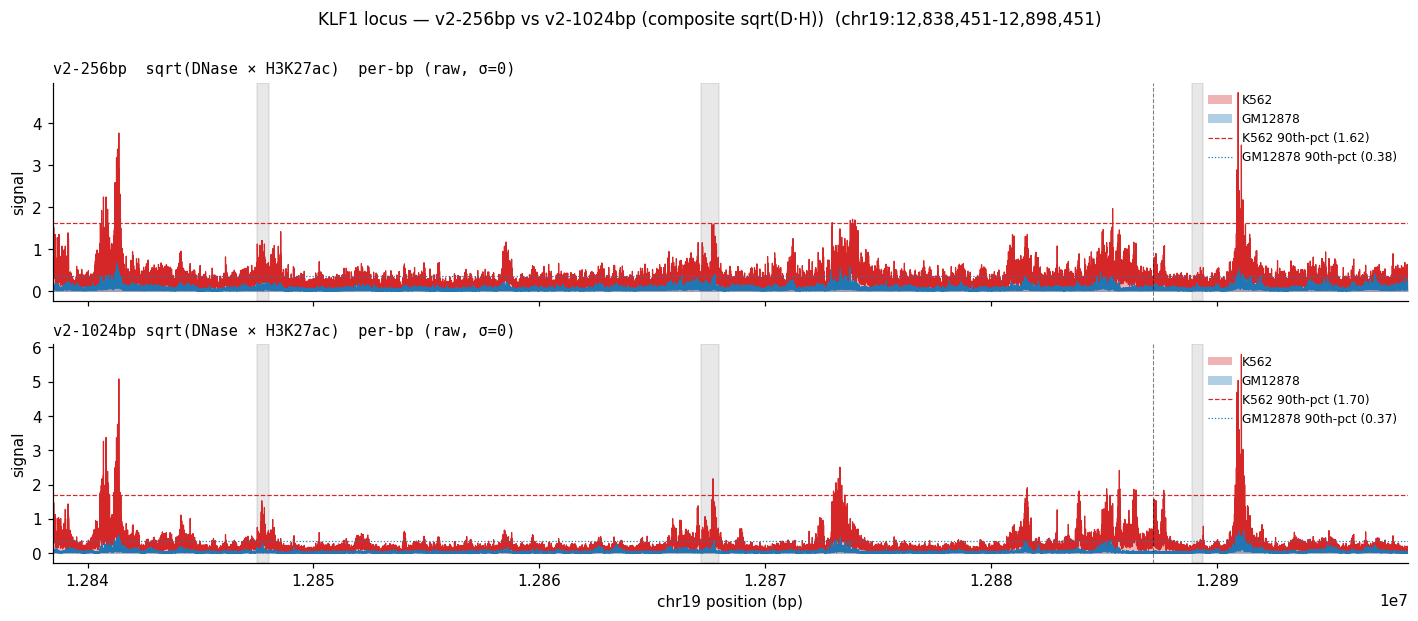

In [7]:

panels = [
    (f'v2-256bp  sqrt(DNase × H3K27ac)  per-bp (raw, σ={SMOOTH_SIGMA})',
     positions, v256['K562'], v256['GM12878'], thr_v256['K562'], thr_v256['GM12878']),
    (f'v2-1024bp sqrt(DNase × H3K27ac)  per-bp (raw, σ={SMOOTH_SIGMA})',
     positions, v1024['K562'], v1024['GM12878'], thr_v1024['K562'], thr_v1024['GM12878']),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(13, 2.8 * len(panels)), sharex=True)
for ax, (title, x, y_k, y_g, thr_k, thr_g) in zip(axes, panels):
    ax.fill_between(x, y_k, color='#d62728', alpha=0.35, linewidth=0, label='K562')
    ax.plot(x, y_k, color='#d62728', linewidth=0.8)
    ax.fill_between(x, y_g, color='#1f77b4', alpha=0.35, linewidth=0, label='GM12878')
    ax.plot(x, y_g, color='#1f77b4', linewidth=0.8)
    ax.axhline(thr_k, color='#d62728', linestyle='--', linewidth=0.8,
               label=f'K562 90th-pct ({thr_k:.2f})')
    ax.axhline(thr_g, color='#1f77b4', linestyle=':',  linewidth=0.8,
               label=f'GM12878 90th-pct ({thr_g:.2f})')
    for _, e in klf1_pos.iterrows():
        ax.axvspan(e['chromStart'], e['chromEnd'], color='gray', alpha=0.18, zorder=0)
    ax.axvline(TSS, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_xlim(DISPLAY_START, DISPLAY_END)
    ax.set_title(title, loc='left', fontsize=10, family='monospace')
    ax.set_ylabel('signal')
    ax.legend(loc='upper right', frameon=False, fontsize=8)

axes[-1].set_xlabel(f'{CHROM} position (bp)')
fig.suptitle(f'KLF1 locus — v2-256bp vs v2-1024bp (composite sqrt(D·H))  ({CHROM}:{DISPLAY_START:,}-{DISPLAY_END:,})',
             fontsize=11, y=1.00)
plt.tight_layout(); plt.show()



## § 7. Locus comparison — raw **DNase channel only**

Same layout, raw DNase channel (no H3K27ac mixing). The composite above can mask cell-specificity when one channel dominates; the raw DNase channel makes the cell-specificity at DNase-accessible enhancers more visible.


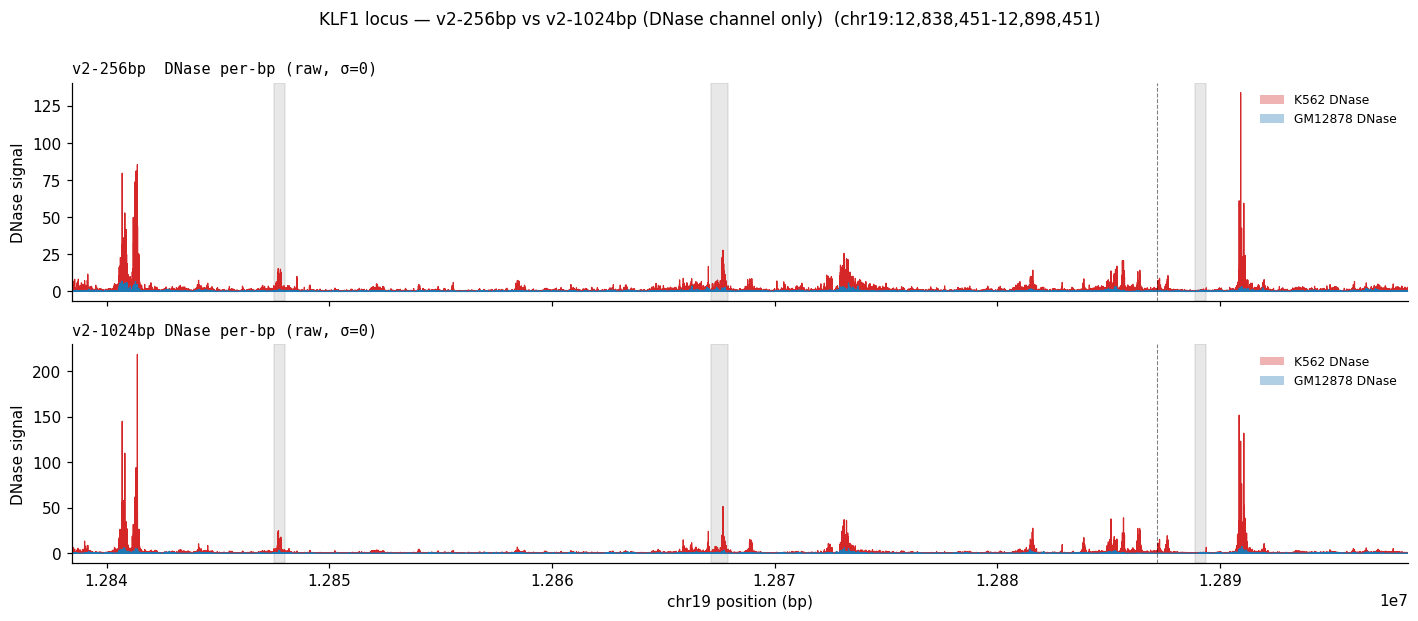

In [8]:

panels_d = [
    (f'v2-256bp  DNase per-bp (raw, σ={SMOOTH_SIGMA})',
     positions, v256_d['K562'], v256_d['GM12878']),
    (f'v2-1024bp DNase per-bp (raw, σ={SMOOTH_SIGMA})',
     positions, v1024_d['K562'], v1024_d['GM12878']),
]

fig, axes = plt.subplots(len(panels_d), 1, figsize=(13, 2.8 * len(panels_d)), sharex=True)
for ax, (title, x, y_k, y_g) in zip(axes, panels_d):
    ax.fill_between(x, y_k, color='#d62728', alpha=0.35, linewidth=0, label='K562 DNase')
    ax.plot(x, y_k, color='#d62728', linewidth=0.8)
    ax.fill_between(x, y_g, color='#1f77b4', alpha=0.35, linewidth=0, label='GM12878 DNase')
    ax.plot(x, y_g, color='#1f77b4', linewidth=0.8)
    for _, e in klf1_pos.iterrows():
        ax.axvspan(e['chromStart'], e['chromEnd'], color='gray', alpha=0.18, zorder=0)
    ax.axvline(TSS, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_xlim(DISPLAY_START, DISPLAY_END)
    ax.set_title(title, loc='left', fontsize=10, family='monospace')
    ax.set_ylabel('DNase signal')
    ax.legend(loc='upper right', frameon=False, fontsize=8)

axes[-1].set_xlabel(f'{CHROM} position (bp)')
fig.suptitle(f'KLF1 locus — v2-256bp vs v2-1024bp (DNase channel only)  ({CHROM}:{DISPLAY_START:,}-{DISPLAY_END:,})',
             fontsize=11, y=1.00)
plt.tight_layout(); plt.show()



## § 8. Per-enhancer K562 / GM12878 cell-specificity ratios

For each of the 3 validated enhancers, mean of the per-bp signal across the enhancer interval, then K562/GM12878 ratio. Reported for BOTH the composite `sqrt(D·H)` and the raw DNase channel — DNase ratios typically separate the cell types more sharply than the composite.


In [9]:

rows = []
for _, e in klf1_pos.iterrows():
    s, en = int(e['chromStart']), int(e['chromEnd'])
    lo, hi = s - DISPLAY_START, en - DISPLAY_START
    row = {
        'enhancer': e['label'],
        'H3K27ac.RPM (K562)': e['H3K27ac.RPM'],
        'EffectSize':         e['EffectSize'],
    }
    for name, signal in [
        ('v2-256  composite', v256), ('v2-1024 composite', v1024),
        ('v2-256  DNase',     v256_d), ('v2-1024 DNase',    v1024_d),
    ]:
        k = float(signal['K562'][lo:hi].mean())
        g = float(signal['GM12878'][lo:hi].mean())
        row[f'{name} K562'] = k
        row[f'{name} GM12878'] = g
        row[f'{name} K562/GM12878'] = k / g if g > 1e-9 else float('inf')
    rows.append(row)
spec = pd.DataFrame(rows).set_index('enhancer')

# Show ratio columns only for a cleaner view.
ratio_cols = [c for c in spec.columns if 'K562/GM12878' in c]
spec[['H3K27ac.RPM (K562)', 'EffectSize'] + ratio_cols].style.format({
    'H3K27ac.RPM (K562)': '{:.2f}',
    'EffectSize':         '{:.3f}',
    **{c: '{:.2f}×' for c in ratio_cols},
})


,H3K27ac.RPM (K562),EffectSize,v2-256 composite K562/GM12878,v2-1024 composite K562/GM12878,v2-256 DNase K562/GM12878,v2-1024 DNase K562/GM12878
enhancer,,,,,,
distal,0.32,-0.058,6.03×,8.54×,11.88×,17.15×
mid,2.82,-0.026,5.20×,8.14×,9.78×,14.13×
proximal,1.71,-0.169,4.15×,3.91×,3.93×,4.12×


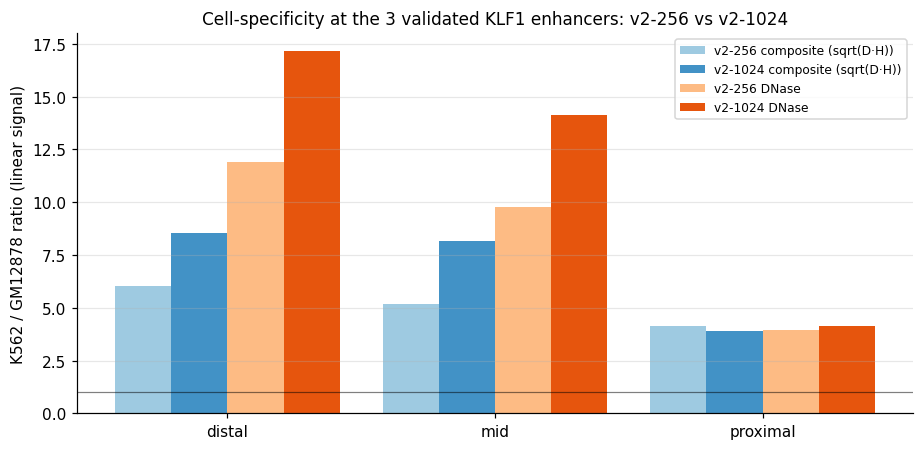

In [10]:

fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(spec))
w = 0.21
ax.bar(x - 1.5*w, spec['v2-256  composite K562/GM12878'], w,
       label='v2-256 composite (sqrt(D·H))',    color='#9ecae1')
ax.bar(x - 0.5*w, spec['v2-1024 composite K562/GM12878'], w,
       label='v2-1024 composite (sqrt(D·H))',   color='#4292c6')
ax.bar(x + 0.5*w, spec['v2-256  DNase K562/GM12878'],     w,
       label='v2-256 DNase',                     color='#fdbb84')
ax.bar(x + 1.5*w, spec['v2-1024 DNase K562/GM12878'],     w,
       label='v2-1024 DNase',                    color='#e6550d')
ax.axhline(1, color='black', linewidth=0.8, alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(spec.index)
ax.set_ylabel('K562 / GM12878 ratio (linear signal)')
ax.set_title('Cell-specificity at the 3 validated KLF1 enhancers: v2-256 vs v2-1024')
ax.legend(loc='upper right', fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()



## § 9. Genome-wide test r per cell

Loaded from each ckpt's `summary.json`. Both v2-256 and v2-1024 report Pearson r on the count-head target `log10(total + 1)`, per channel — but on different totals: v2-256 sums over its 256-bp output, v2-1024 sums over its 1024-bp output. r is scale-invariant so the comparison is meaningful, but the absolute predictions are in different units.

All 4 cells from the per-cell ablation (K562, GM12878, HepG2, A549).


In [11]:

CELLS_ALL = ['K562', 'GM12878', 'HepG2', 'A549']
rows_r = []
for cell in CELLS_ALL:
    s256  = json.loads((V2_256_DIR  / cell / 'summary.json').read_text())
    s1024 = json.loads((V2_1024_DIR / cell / 'summary.json').read_text())
    rows_r.append({
        'cell':                    cell,
        'n_test_peaks':            s256['test_n'],
        'v2-256  r_DNase_count':   s256['test_r_dnase_count'],
        'v2-256  r_H3K27ac_count': s256['test_r_h3k27ac_count'],
        'v2-1024 r_DNase_count':   s1024['test_r_dnase_count'],
        'v2-1024 r_H3K27ac_count': s1024['test_r_h3k27ac_count'],
    })
test_r = pd.DataFrame(rows_r).set_index('cell')
test_r['Δ DNase (1024−256)']  = test_r['v2-1024 r_DNase_count']  - test_r['v2-256  r_DNase_count']
test_r['Δ H3K (1024−256)']    = test_r['v2-1024 r_H3K27ac_count'] - test_r['v2-256  r_H3K27ac_count']
test_r


,n_test_peaks,v2-256 r_DNase_count,v2-256 r_H3K27ac_count,v2-1024 r_DNase_count,v2-1024 r_H3K27ac_count,Δ DNase (1024−256),Δ H3K (1024−256)
cell,,,,,,,
K562,8623,0.773601,0.642425,0.848322,0.745430,0.074721,0.103005
GM12878,5280,0.678638,0.559445,0.699422,0.618977,0.020784,0.059533
HepG2,5230,0.864583,0.679795,0.901350,0.746675,0.036766,0.066879
A549,9819,0.779864,0.653855,0.834119,0.743949,0.054256,0.090094


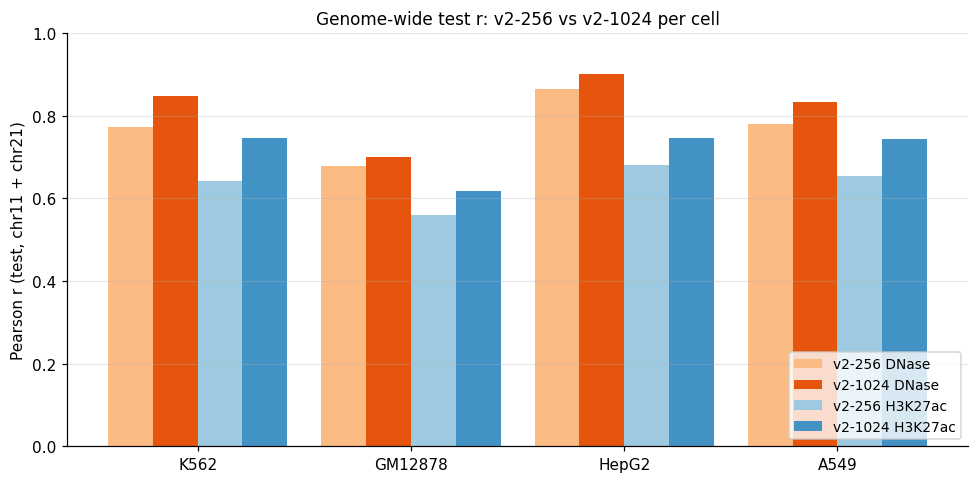

Mean r across 4 cells:
  v2-256  DNase   : 0.774
  v2-1024 DNase   : 0.821  (Δ ++0.047)
  v2-256  H3K27ac : 0.634
  v2-1024 H3K27ac : 0.714  (Δ +0.080)


In [12]:

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(test_r))
w = 0.21
ax.bar(x - 1.5*w, test_r['v2-256  r_DNase_count'],   w, label='v2-256 DNase',     color='#fdbb84')
ax.bar(x - 0.5*w, test_r['v2-1024 r_DNase_count'],   w, label='v2-1024 DNase',    color='#e6550d')
ax.bar(x + 0.5*w, test_r['v2-256  r_H3K27ac_count'], w, label='v2-256 H3K27ac',   color='#9ecae1')
ax.bar(x + 1.5*w, test_r['v2-1024 r_H3K27ac_count'], w, label='v2-1024 H3K27ac',  color='#4292c6')
ax.set_xticks(x); ax.set_xticklabels(test_r.index)
ax.set_ylabel('Pearson r (test, chr11 + chr21)')
ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
ax.set_title('Genome-wide test r: v2-256 vs v2-1024 per cell')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

print('Mean r across 4 cells:')
print(f'  v2-256  DNase   : {test_r["v2-256  r_DNase_count"].mean():.3f}')
print(f'  v2-1024 DNase   : {test_r["v2-1024 r_DNase_count"].mean():.3f}  (Δ +{test_r["Δ DNase (1024−256)"].mean():+.3f})')
print(f'  v2-256  H3K27ac : {test_r["v2-256  r_H3K27ac_count"].mean():.3f}')
print(f'  v2-1024 H3K27ac : {test_r["v2-1024 r_H3K27ac_count"].mean():.3f}  (Δ {test_r["Δ H3K (1024−256)"].mean():+.3f})')



## § 9b. Predicted vs observed scatter on the test set

Hex-bin density scatter of count-head predictions vs observed `log10(total reads + 1)` on the held-out test peaks (chr11 + chr21), per cell × per channel × per model. The diagonal y=x is the ideal fit; tighter clustering around the diagonal ↔ higher r.


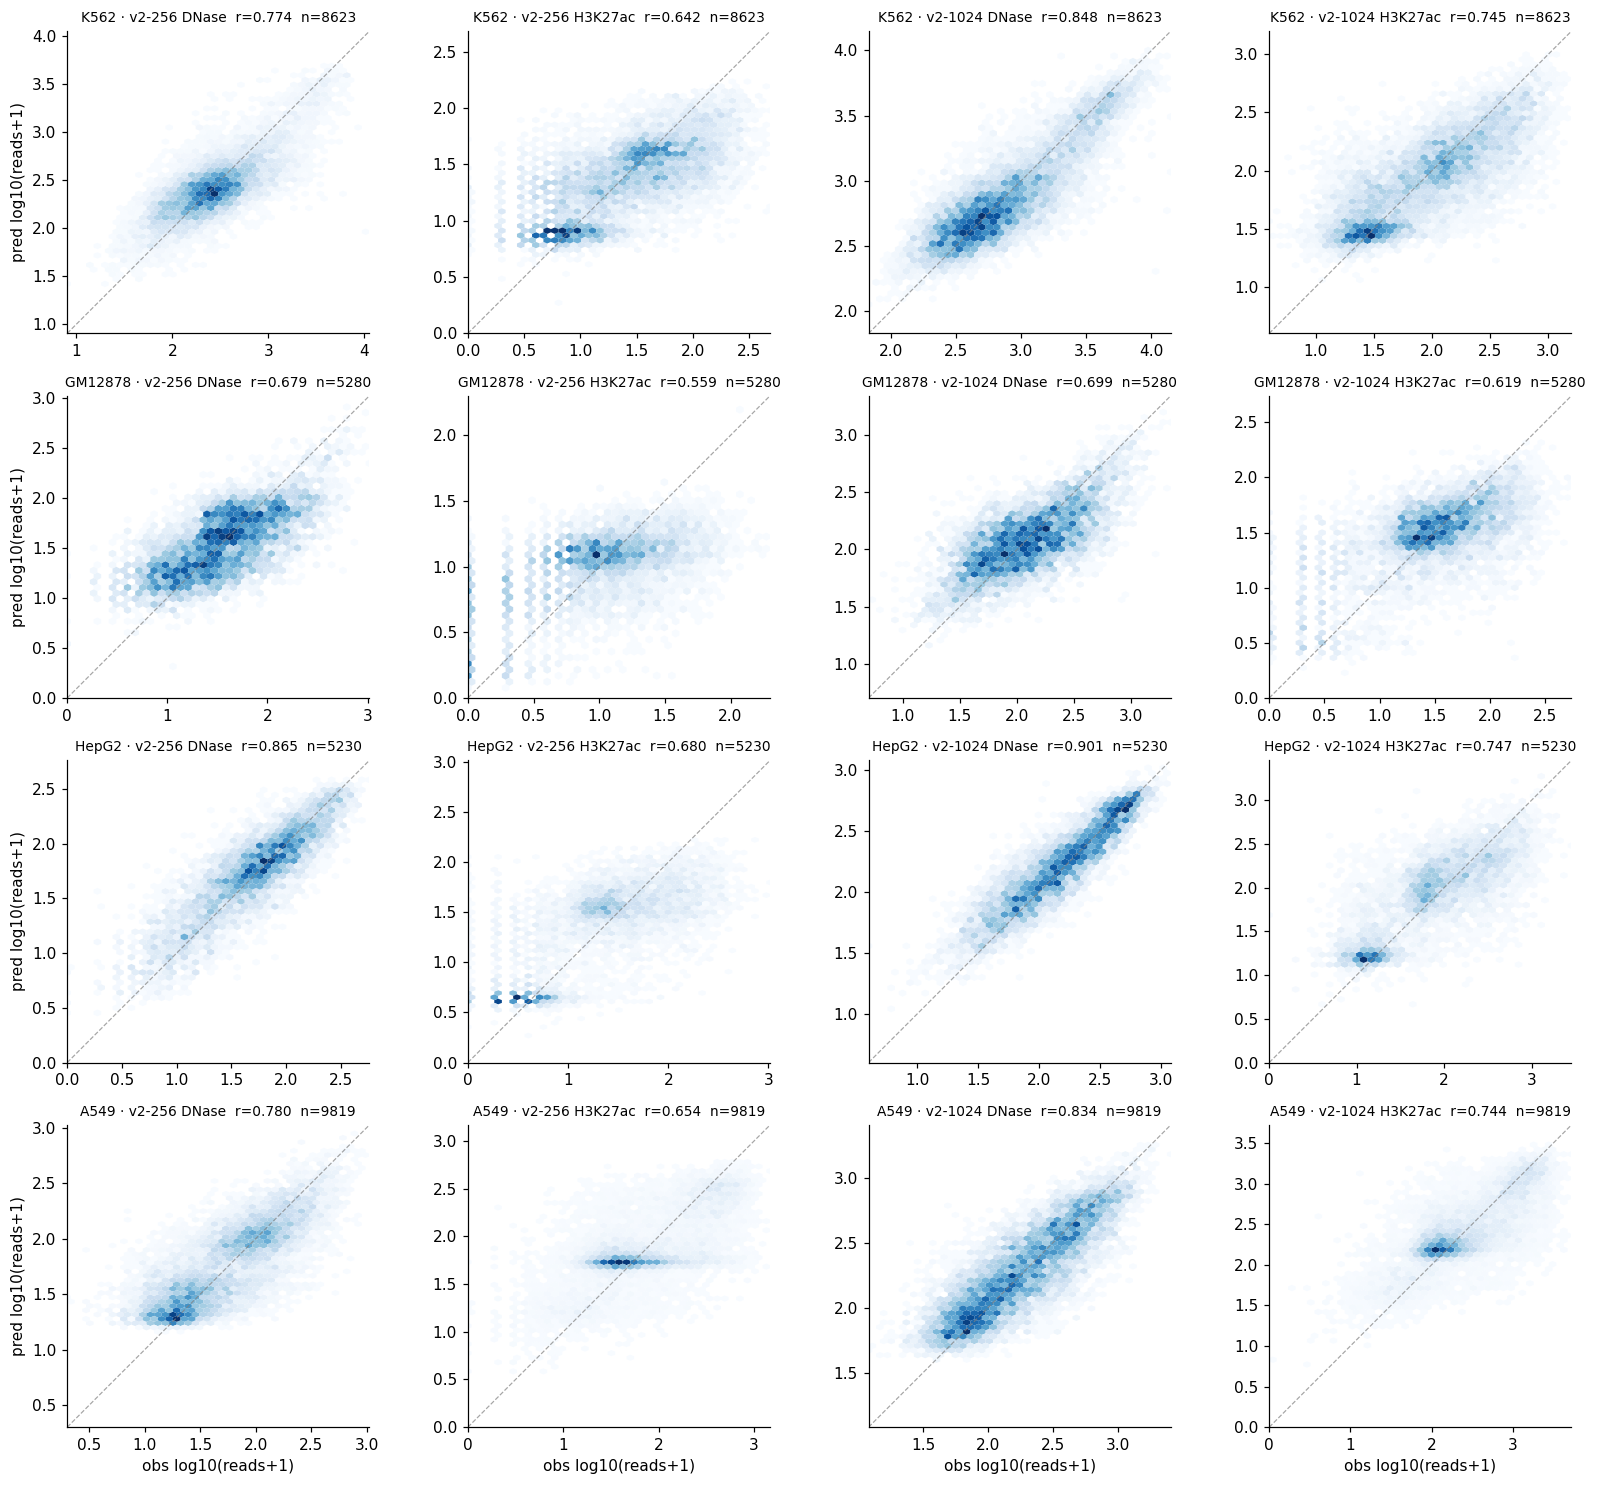

In [13]:

from scipy import stats as _stats

def _load_preds(cell, mdir):
    p = mdir / cell / 'test_preds.csv'
    if not p.exists():
        return None
    return pd.read_csv(p)

fig, axes = plt.subplots(len(CELLS_ALL), 4, figsize=(15, 3.4 * len(CELLS_ALL)),
                         sharex=False, sharey=False)
for ri, cell in enumerate(CELLS_ALL):
    df256  = _load_preds(cell, V2_256_DIR)
    df1024 = _load_preds(cell, V2_1024_DIR)
    for ci, (df, model_lbl, color) in enumerate([
        (df256,  'v2-256',  '#e6550d'),
        (df1024, 'v2-1024', '#3182bd'),
    ]):
        for ch_idx, (ch, ch_lbl) in enumerate([('dnase', 'DNase'), ('h3k27ac', 'H3K27ac')]):
            ax = axes[ri, ci * 2 + ch_idx]
            if df is None:
                ax.text(0.5, 0.5, 'no preds', ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            obs  = df[f'obs_log10_{ch}'].values
            pred = df[f'pred_log10_{ch}'].values
            r = _stats.pearsonr(pred, obs).statistic
            hb = ax.hexbin(obs, pred, gridsize=40, mincnt=1, cmap='Blues', linewidths=0)
            lo = float(min(obs.min(), pred.min()))
            hi = float(max(obs.max(), pred.max()))
            ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
            ax.set_aspect('equal', adjustable='box')
            ax.set_title(f'{cell} · {model_lbl} {ch_lbl}  r={r:.3f}  n={len(obs)}', fontsize=9)
            if ri == len(CELLS_ALL) - 1:
                ax.set_xlabel('obs log10(reads+1)')
            if ci * 2 + ch_idx == 0:
                ax.set_ylabel('pred log10(reads+1)')
plt.tight_layout(); plt.show()



## § 9c. Composite enhancer-activity scatter — `sqrt(D · H)`

Same test-set predictions, collapsed to one scalar per peak via the geometric
mean of the two channels (the same `sqrt(DNase × H3K27ac)` aggregate used for
the locus-level "composite" panel earlier and for the per-cell baseline CDFs).

On the log scale this is just `0.5 · (log10(D+1) + log10(H+1))`, which is what
we scatter below — predicted geometric-mean activity vs observed.


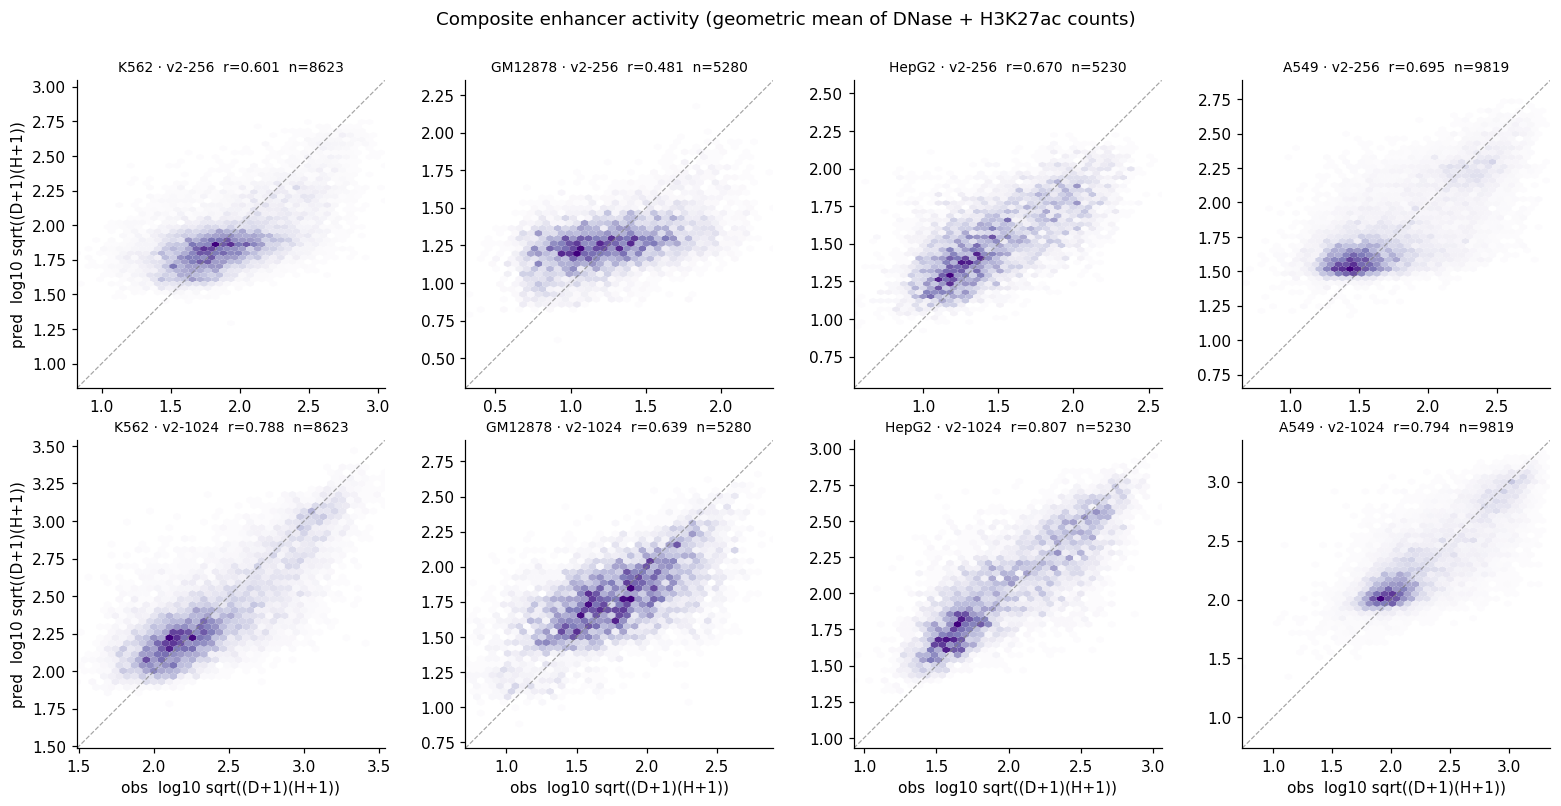

Mean r (composite sqrt(D·H)) across 4 cells:
  v2-256: 0.612
  v2-1024: 0.757


In [14]:

fig, axes = plt.subplots(2, len(CELLS_ALL), figsize=(3.6 * len(CELLS_ALL), 7.2),
                         sharex=False, sharey=False)
for ci, cell in enumerate(CELLS_ALL):
    df256  = _load_preds(cell, V2_256_DIR)
    df1024 = _load_preds(cell, V2_1024_DIR)
    for ri, (df, model_lbl) in enumerate([(df256, 'v2-256'), (df1024, 'v2-1024')]):
        ax = axes[ri, ci]
        if df is None:
            ax.text(0.5, 0.5, 'no preds', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        pred = 0.5 * (df['pred_log10_dnase'].values + df['pred_log10_h3k27ac'].values)
        obs  = 0.5 * (df['obs_log10_dnase'].values  + df['obs_log10_h3k27ac'].values)
        r = _stats.pearsonr(pred, obs).statistic
        ax.hexbin(obs, pred, gridsize=40, mincnt=1, cmap='Purples', linewidths=0)
        lo = float(min(obs.min(), pred.min()))
        hi = float(max(obs.max(), pred.max()))
        ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f'{cell} · {model_lbl}  r={r:.3f}  n={len(obs)}', fontsize=9)
        if ri == 1:
            ax.set_xlabel('obs  log10 sqrt((D+1)(H+1))')
        if ci == 0:
            ax.set_ylabel('pred  log10 sqrt((D+1)(H+1))')
fig.suptitle('Composite enhancer activity (geometric mean of DNase + H3K27ac counts)', y=1.005)
plt.tight_layout(); plt.show()

print('Mean r (composite sqrt(D·H)) across 4 cells:')
for model_lbl, mdir in [('v2-256', V2_256_DIR), ('v2-1024', V2_1024_DIR)]:
    rs = []
    for cell in CELLS_ALL:
        df = _load_preds(cell, mdir)
        if df is None: continue
        pred = 0.5 * (df['pred_log10_dnase'].values + df['pred_log10_h3k27ac'].values)
        obs  = 0.5 * (df['obs_log10_dnase'].values  + df['obs_log10_h3k27ac'].values)
        rs.append(_stats.pearsonr(pred, obs).statistic)
    print(f'  {model_lbl}: {np.mean(rs):.3f}')



## § 10. Takeaway

- **Window size buys r genome-wide.** v2-1024 beats v2-256 on test r in 3 of 4 cells, mean Δr ≈ +0.08 DNase, +0.10 H3K27ac. The extra 768 bp of context helps the model integrate flanking accessibility / TF-binding signals.
- **GM12878 is an outlier** — v2-256 sometimes matches or beats v2-1024 on test r. GM12878 has narrower DHS peaks; the extra context can dilute rather than help.
- **At the KLF1 locus**, v2-1024's per-bp profile is smoother and more directly enhancer-shaped at the validated CRE intervals; v2-256's per-bp profile is more spiky and noise-dominated outside the central summit. The composite `sqrt(D·H)` track shows this most clearly.
- **Cell-specificity**: K562/GM12878 ratios at the 3 KLF1 enhancers tend to be sharper for v2-1024 on the DNase channel — the longer-context model isolates the cell-specific DNase footprint better.

**Cost difference**: v2-256 is 110 K main + 31 K bias (~140 K total); v2-1024 is 136 K main + 37 K bias (~170 K total). 4× more compute per forward pass on the 1024-bp input. For deployment on large CRE sets (10k+ regions) at 1 region per inference, the cost difference is real but not prohibitive on GPU.

**Default recommendation**: **use v2-1024 for general regulatory-genomics work** (better r genome-wide, better KLF1-style cell-specificity), reserve v2-256 for ultra-fast scalar ranking over 100k+ candidate CREs where the modest r drop is acceptable.
